In [12]:
# Import packages
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import matplotlib.pyplot as plt
import milopy.core as milo
import milopy.plot as milopl
import re

In [55]:
import rpy2
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri, numpy2ri
pandas2ri.activate()
numpy2ri.activate()

edgeR = importr("edgeR")
limma = importr("limma")
stats = importr("stats")
base = importr("base")

In [9]:
def _try_import_bioc_library(name):
    try:
        _r_lib = importr(name)
        return _r_lib
    except PackageNotInstalledError:
        raise RuntimeError(
            f"Install Bioconductor library `{name!r}` first as `BiocManager::install({name!r}).`"
        )

In [3]:
adata_primary_base=sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_noreplicates/stratify/Primary_BASE.h5ad')

In [4]:
milo.make_nhoods(adata_primary_base, prop=0.1)

In [5]:
milo.count_nhoods(adata_primary_base, sample_col="Sample")

In [6]:
adata_primary_base.obs["ZFP_Expression_continuous"] = adata_primary_base.obs["ZFP_Expression"].cat.codes

In [8]:
adata_primary_base.obs["ZFP_Expression_continuous"]

146P_BASE_shCTRL_CTCACTGCATAGAATG-1         0
146P_BASE_shCTRL_TTGACCCTCAATCCAG-1         0
146P_BASE_shCTRL_TTTATGCTCATAGACC-1         0
146P_BASE_shCTRL_CGTAGTACATGGGCAA-1         0
146P_BASE_shCTRL_CTGCGAGCAATTCTCT-1         0
                                           ..
146P_BASE_shZFP36L2_3_GTCCTCAGTCATCACA-1    1
146P_BASE_shZFP36L2_3_CCTCTAGAGTACGTCT-1    1
146P_BASE_shZFP36L2_3_TGTAGACTCGGAACTT-1    1
146P_BASE_shZFP36L2_3_CATTGTTTCTAGTGTG-1    1
146P_BASE_shZFP36L2_3_CAGCAATAGTTGGAAT-1    1
Name: ZFP_Expression_continuous, Length: 7318, dtype: int8

In [14]:
nhood_adata = adata_primary_base.uns["nhood_adata"]
design="~ZFP_Expression_continuous"
covariates = [x.strip(" ") for x in set(re.split('\\+|\\*', design.lstrip("~ ")))]

In [17]:
sample_col = nhood_adata.uns["sample_col"]
try:
    nhoods_var = adata_primary_base.obs[covariates + [sample_col]].drop_duplicates()
except KeyError:
    missing_cov = [
        x for x in covariates if x not in nhood_adata.var.columns]
    raise KeyError(
        'Covariates {c} are not columns in adata.obs'.format(
            c=" ".join(missing_cov))
    )
sample_col

'Sample'

In [19]:
nhoods_var = nhoods_var[covariates + [sample_col]]
nhoods_var

,ZFP_Expression_continuous,Sample
146P_BASE_shCTRL_CTCACTGCATAGAATG-1,0,146_P_BASE_CTRL_1
146P_BASE_shZFP36L2_3_GAGGGTACATGAAAGT-1,1,146_P_BASE_ZFPKD_1


In [21]:
nhoods_var.index = nhoods_var[sample_col].astype("str")
nhoods_var

,ZFP_Expression_continuous,Sample
Sample,,
146_P_BASE_CTRL_1,0,146_P_BASE_CTRL_1
146_P_BASE_ZFPKD_1,1,146_P_BASE_ZFPKD_1


In [22]:
nhoods_var = nhoods_var[covariates]
nhoods_var

,ZFP_Expression_continuous
Sample,
146_P_BASE_CTRL_1,0
146_P_BASE_ZFPKD_1,1


In [24]:
try:
    assert nhoods_var.loc[nhood_adata.var_names].shape[0] == len(
        nhood_adata.var_names)
except:
    raise ValueError(
        "Covariates cannot be unambiguously assigned to each sample -- each sample value should match a single covariate value")
nhood_adata.var = nhoods_var.loc[nhood_adata.var_names]
nhood_adata

AnnData object with n_obs × n_vars = 585 × 2
    obs: 'index_cell', 'kth_distance'
    var: 'ZFP_Expression_continuous'
    uns: 'sample_col'

In [27]:
# Get design dataframe
try:
    design_df = nhood_adata.var[covariates]
except KeyError:
    missing_cov = [
        x for x in covariates if x not in nhood_adata.var.columns]
    raise KeyError(
        'Covariates {c} are not columns in adata.uns["nhood_adata"].var'.format(
            c=" ".join(missing_cov))
    )
design_df

,ZFP_Expression_continuous
146_P_BASE_CTRL_1,0
146_P_BASE_ZFPKD_1,1


In [31]:
subset_samples=None
add_intercept=True
model_contrasts=None
# Get count matrix
count_mat = nhood_adata.X.toarray()
lib_size = count_mat.sum(0)

# Filter out samples with zero counts
keep_smp = lib_size > 0

# Subset samples
if subset_samples is not None:
    keep_smp = keep_smp & nhood_adata.var_names.isin(subset_samples)

design_df = design_df[keep_smp]
for i, e in enumerate(design_df.columns):
    if design_df.dtypes[i].name == 'category':
        design_df[e] = design_df[e].cat.remove_unused_categories()

# Filter out nhoods with zero counts
# (they can appear after sample filtering)
keep_nhoods = count_mat[:, keep_smp].sum(1) > 0

# Define model matrix
if not add_intercept or model_contrasts is not None:
    design = design + ' + 0'
model = stats.model_matrix(object=stats.formula(
    design), data=design_df)

In [35]:
design_df

,ZFP_Expression_continuous
146_P_BASE_CTRL_1,0
146_P_BASE_ZFPKD_1,1


In [32]:
model

array([[1., 0.],
       [1., 1.]])

In [38]:
# Fit NB-GLM
dge = edgeR.DGEList(counts=count_mat[keep_nhoods, :][:, keep_smp], lib_size=lib_size[keep_smp])
print(dge)

An object of class "DGEList"
$counts
  Sample1 Sample2
1       7       5
2      22       9
3      14       8
4      17       2
5      14       7
580 more rows ...

$samples
        group lib.size norm.factors
Sample1     1     6307            1
Sample2     1     6410            1




In [40]:
dge = edgeR.calcNormFactors(dge, method="TMM")
print(dge)

An object of class "DGEList"
$counts
  Sample1 Sample2
1       7       5
2      22       9
3      14       8
4      17       2
5      14       7
580 more rows ...

$samples
        group lib.size norm.factors
Sample1     1     6307    1.1016976
Sample2     1     6410    0.9076901




In [42]:
dge = edgeR.estimateDisp(dge, model)
print(dge)

An object of class "DGEList"
$counts
  Sample1 Sample2
1       7       5
2      22       9
3      14       8
4      17       2
5      14       7
580 more rows ...

$samples
        group lib.size norm.factors
Sample1     1     6307    1.1016976
Sample2     1     6410    0.9076901

$design
     [,1] [,2]
[1,]    1    0
[2,]    1    1

$common.dispersion
[1] NA

$trended.dispersion
[1] NA

$tagwise.dispersion
[1] NA

$AveLogCPM
[1] 10.28842 11.40233 10.98315 10.78712 10.92430
580 more elements ...

$trend.method
[1] "locfit"




In [46]:
model

array([[1., 0.],
       [1., 1.]])

In [90]:
def DA_nhoods(adata, design, model_contrasts=None, subset_samples=None, add_intercept=True):
    '''
    This will perform differential neighbourhood abundance testing (using edgeR under the hood)
    - adata
    - design: formula (terms should be columns in adata.uns["nhood_adata"].var)
    - model_contrasts: A string vector that defines the contrasts used to perform DA testing
    - subset_samples: subset of samples (columns in `adata.uns["nhood_adata"].X`) to use for the test
    - add_intercept: whether to include an intercept in the model. If False, this is equivalent to adding + 0 in the design formula.
    When model_contrasts is specified, this is set to False by default. 
    '''
    # Set up rpy2 to run edgeR
    rpy2.robjects.numpy2ri.activate()
    rpy2.robjects.pandas2ri.activate()
    edgeR = _try_import_bioc_library("edgeR")
    limma = _try_import_bioc_library("limma")
    stats = importr("stats")
    base = importr("base")

    nhood_adata = adata.uns["nhood_adata"]
    covariates = [x.strip(" ") for x in set(
        re.split('\\+|\\*', design.lstrip("~ ")))]
    nhood_adata

    # Add covariates used for testing to nhood_adata.var
    sample_col = nhood_adata.uns["sample_col"]
    try:
        nhoods_var = adata.obs[covariates + [sample_col]].drop_duplicates()
    except KeyError:
        missing_cov = [
            x for x in covariates if x not in nhood_adata.var.columns]
        raise KeyError(
            'Covariates {c} are not columns in adata.obs'.format(
                c=" ".join(missing_cov))
        )
    # N.B. This might need some type adjustment!!
    nhoods_var = nhoods_var[covariates + [sample_col]]
    nhoods_var.index = nhoods_var[sample_col].astype("str")

    try:
        assert nhoods_var.loc[nhood_adata.var_names].shape[0] == len(
            nhood_adata.var_names)
    except:
        raise ValueError(
            "Covariates cannot be unambiguously assigned to each sample -- each sample value should match a single covariate value")
    nhood_adata.var = nhoods_var.loc[nhood_adata.var_names]
    # Get design dataframe
    try:
        design_df = nhood_adata.var[covariates]
    except KeyError:
        missing_cov = [
            x for x in covariates if x not in nhood_adata.var.columns]
        raise KeyError(
            'Covariates {c} are not columns in adata.uns["nhood_adata"].var'.format(
                c=" ".join(missing_cov))
        )

    # Get count matrix
    count_mat = nhood_adata.X.toarray()
    lib_size = count_mat.sum(0)

    # Filter out samples with zero counts
    keep_smp = lib_size > 0

    # Subset samples
    if subset_samples is not None:
        keep_smp = keep_smp & nhood_adata.var_names.isin(subset_samples)
    
    design_df = design_df[keep_smp]
    for i, e in enumerate(design_df.columns):
        if design_df.dtypes[i].name == 'category':
            design_df[e] = design_df[e].cat.remove_unused_categories()

    # Filter out nhoods with zero counts
    # (they can appear after sample filtering)
    keep_nhoods = count_mat[:, keep_smp].sum(1) > 0

    # Define model matrix
    if not add_intercept or model_contrasts is not None:
        design = design + ' + 0'
    model = stats.model_matrix(object=stats.formula(
        design), data=design_df)

    # Fit NB-GLM
    dge = edgeR.DGEList(
        counts=count_mat[keep_nhoods, :][:, keep_smp], lib_size=lib_size[keep_smp])
    dge = edgeR.calcNormFactors(dge, method="TMM")
    dge = edgeR.estimateCommonDisp(dge, model)
    fit = edgeR.glmFit(dge, model, robust=True)
    
    # Test
    n_coef = model.shape[1]
    if model_contrasts is not None:
        r_str = '''
        get_model_cols <- function(design_df, design){
            m = model.matrix(object=formula(design), data=design_df)
            return(colnames(m))
        }
        '''
        get_model_cols = STAP(r_str, "get_model_cols")
        model_mat_cols = get_model_cols.get_model_cols(design_df, design)
        model_df = pd.DataFrame(model)
        model_df.columns = model_mat_cols
        try:
            mod_contrast = limma.makeContrasts(
                contrasts=model_contrasts, levels=model_df)
        except:
            raise ValueError(
                "Model contrasts must be in the form 'A-B' or 'A+B'")
        res = base.as_data_frame(edgeR.topTags(edgeR.glmQLFTest(
            fit, contrast=mod_contrast), sort_by='none', n=np.inf))
    else:
        res = base.as_data_frame(edgeR.topTags(
            edgeR.glmLRT(fit, coef=n_coef), sort_by='none', n=np.inf))
#         res = base.as_data_frame(edgeR.topTags(
#             edgeR.glmQLFTest(fit, coef=n_coef), sort_by='none', n=np.inf))

    res = rpy2.robjects.conversion.rpy2py(res)
    if not isinstance(res, pd.DataFrame):
        res = pd.DataFrame(res)

    # Save outputs
    res.index = nhood_adata.obs_names[keep_nhoods]
    if any([x in nhood_adata.obs.columns for x in res.columns]):
        nhood_adata.obs = nhood_adata.obs.drop(res.columns, axis=1)
    nhood_adata.obs = pd.concat([nhood_adata.obs, res], axis=1)

    # Run Graph spatial FDR correction
    _graph_spatialFDR(adata)


In [67]:
def _graph_spatialFDR(adata):
    '''
    FDR correction weighted on inverse of connectivity of neighbourhoods.
    The distance to the k-th nearest neighbor is used as a measure of connectivity.
    '''

    # use 1/connectivity as the weighting for the weighted BH adjustment from Cydar
    w = 1/adata.uns["nhood_adata"].obs['kth_distance']
    w[np.isinf(w)] = 0

    # Computing a density-weighted q-value.
    pvalues = adata.uns["nhood_adata"].obs["PValue"]
    keep_nhoods = ~pvalues.isna()  #  Filtering in case of test on subset of nhoods
    o = pvalues[keep_nhoods].argsort()
    pvalues = pvalues[keep_nhoods][o]
    w = w[keep_nhoods][o]

    adjp = pd.Series(np.zeros(shape=pvalues.shape),
                     index=pvalues.index)
    adjp = (sum(w)*pvalues/np.cumsum(w))[::-1].cummin()[::-1]
    adjp[adjp > 1] = 1

    ## Store in anndata
    adata.uns["nhood_adata"].obs["SpatialFDR"] = np.nan
    adata.uns["nhood_adata"].obs.loc[keep_nhoods, "SpatialFDR"] = adjp


In [69]:
def DA_nhoods(adata, design, model_contrasts=None, subset_samples=None, add_intercept=True):
    '''
    This will perform differential neighbourhood abundance testing (using edgeR under the hood)
    - adata
    - design: formula (terms should be columns in adata.uns["nhood_adata"].var)
    - model_contrasts: A string vector that defines the contrasts used to perform DA testing
    - subset_samples: subset of samples (columns in `adata.uns["nhood_adata"].X`) to use for the test
    - add_intercept: whether to include an intercept in the model. If False, this is equivalent to adding + 0 in the design formula.
    When model_contrasts is specified, this is set to False by default. 
    '''
    # Set up rpy2 to run edgeR
    rpy2.robjects.numpy2ri.activate()
    rpy2.robjects.pandas2ri.activate()
    edgeR = _try_import_bioc_library("edgeR")
    limma = _try_import_bioc_library("limma")
    stats = importr("stats")
    base = importr("base")

    nhood_adata = adata.uns["nhood_adata"]
    covariates = [x.strip(" ") for x in set(
        re.split('\\+|\\*', design.lstrip("~ ")))]
    nhood_adata

    # Add covariates used for testing to nhood_adata.var
    sample_col = nhood_adata.uns["sample_col"]
    try:
        nhoods_var = adata.obs[covariates + [sample_col]].drop_duplicates()
    except KeyError:
        missing_cov = [
            x for x in covariates if x not in nhood_adata.var.columns]
        raise KeyError(
            'Covariates {c} are not columns in adata.obs'.format(
                c=" ".join(missing_cov))
        )
    # N.B. This might need some type adjustment!!
    nhoods_var = nhoods_var[covariates + [sample_col]]
    nhoods_var.index = nhoods_var[sample_col].astype("str")

    try:
        assert nhoods_var.loc[nhood_adata.var_names].shape[0] == len(
            nhood_adata.var_names)
    except:
        raise ValueError(
            "Covariates cannot be unambiguously assigned to each sample -- each sample value should match a single covariate value")
    nhood_adata.var = nhoods_var.loc[nhood_adata.var_names]
    # Get design dataframe
    try:
        design_df = nhood_adata.var[covariates]
    except KeyError:
        missing_cov = [
            x for x in covariates if x not in nhood_adata.var.columns]
        raise KeyError(
            'Covariates {c} are not columns in adata.uns["nhood_adata"].var'.format(
                c=" ".join(missing_cov))
        )

    # Get count matrix
    count_mat = nhood_adata.X.toarray()
    lib_size = count_mat.sum(0)

    # Filter out samples with zero counts
    keep_smp = lib_size > 0

    # Subset samples
    if subset_samples is not None:
        keep_smp = keep_smp & nhood_adata.var_names.isin(subset_samples)
    
    design_df = design_df[keep_smp]
    for i, e in enumerate(design_df.columns):
        if design_df.dtypes[i].name == 'category':
            design_df[e] = design_df[e].cat.remove_unused_categories()

    # Filter out nhoods with zero counts
    # (they can appear after sample filtering)
    keep_nhoods = count_mat[:, keep_smp].sum(1) > 0

    # Define model matrix
    if not add_intercept or model_contrasts is not None:
        design = design + ' + 0'
    model = stats.model_matrix(object=stats.formula(
        design), data=design_df)


In [91]:
DA_nhoods(adata_primary_base, design="~ZFP_Expression_continuous")

In [86]:
# Fit NB-GLM
dge = edgeR.DGEList(counts=count_mat[keep_nhoods, :][:, keep_smp], lib_size=lib_size[keep_smp])

In [87]:
dge = edgeR.calcNormFactors(dge, method="TMM")
dge = edgeR.estimateCommonDisp(dge, model)

In [88]:
dge = edgeR.estimateDisp(dge, model)

In [89]:
fit = edgeR.glmFit(dge, model)

  NA dispersions not allowed


 



RRuntimeError: Error in glmFit.default(y = y$counts, design = design, dispersion = dispersion,  : 
  NA dispersions not allowed


In [ ]:

# Test
n_coef = model.shape[1]
if model_contrasts is not None:
    r_str = '''
    get_model_cols <- function(design_df, design){
        m = model.matrix(object=formula(design), data=design_df)
        return(colnames(m))
    }
    '''
    get_model_cols = STAP(r_str, "get_model_cols")
    model_mat_cols = get_model_cols.get_model_cols(design_df, design)
    model_df = pd.DataFrame(model)
    model_df.columns = model_mat_cols
    try:
        mod_contrast = limma.makeContrasts(
            contrasts=model_contrasts, levels=model_df)
    except:
        raise ValueError(
            "Model contrasts must be in the form 'A-B' or 'A+B'")
    res = base.as_data_frame(edgeR.topTags(edgeR.glmQLFTest(
        fit, contrast=mod_contrast), sort_by='none', n=np.inf))
else:
    res = base.as_data_frame(edgeR.topTags(
        edgeR.glmQLFTest(fit, coef=n_coef), sort_by='none', n=np.inf))
res = rpy2.robjects.conversion.rpy2py(res)
if not isinstance(res, pd.DataFrame):
    res = pd.DataFrame(res)

# Save outputs
res.index = nhood_adata.obs_names[keep_nhoods]
if any([x in nhood_adata.obs.columns for x in res.columns]):
    nhood_adata.obs = nhood_adata.obs.drop(res.columns, axis=1)
nhood_adata.obs = pd.concat([nhood_adata.obs, res], axis=1)

# Run Graph spatial FDR correction
_graph_spatialFDR(adata)


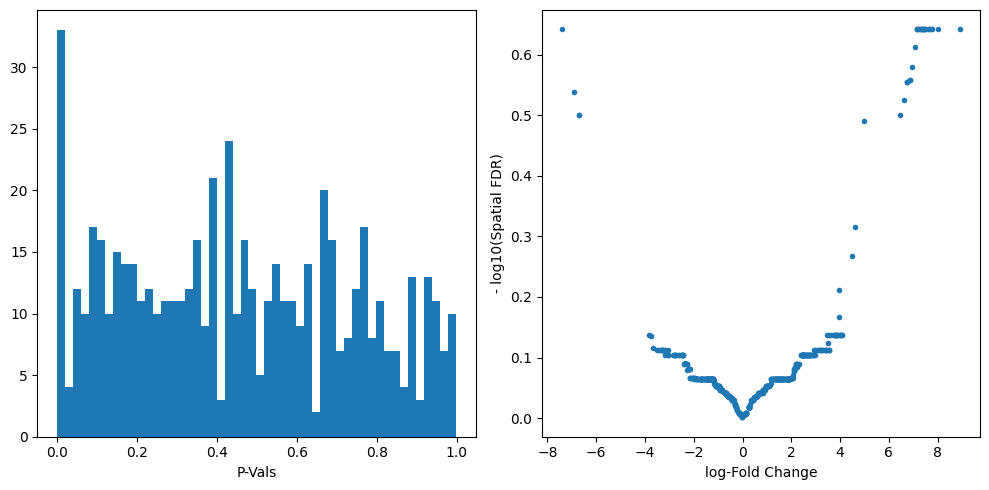

In [92]:
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10,5]
plt.subplot(1,2,1)
plt.hist(adata_primary_base.uns["nhood_adata"].obs.PValue, bins=50);
plt.xlabel("P-Vals");
plt.subplot(1,2,2)
plt.plot(adata_primary_base.uns["nhood_adata"].obs.logFC, -np.log10(adata_primary_base.uns["nhood_adata"].obs.SpatialFDR), '.');
plt.xlabel("log-Fold Change");
plt.ylabel("- log10(Spatial FDR)");
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

In [93]:
adata_primary_base

AnnData object with n_obs × n_vars = 7318 × 30693
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance', 'ZFP_Expression_continuous'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells'
    uns: 'diffmap_evals', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'pca', 'phenograph_sizes', 'rank_genes_groups', 'umap', 'var_explained', 'nhood_neighbors_key', 'nhood_adata'
    obsm: 'X_diff